# Praktikum Machine Learning: Bab 3
## Data Preparation Lanjutan: Missing Values, Outlier, dan Imbalanced Data

| | |
|---|---|
| **Nama** | Ahmad Dandi Subhani |
| **NPM** | 202343500126 |
| **Kelas** | R7B |
| **Mata Kuliah** | Machine Learning |
| **Dosen** | Nurfidah Dwitiyanti, M.Si. |

> **Catatan:** notebook ini saya jalankan di Google Colab / Jupyter Notebook. Notebook ini hanya berisi **Latihan Praktikum Modul Bab 3 bagian 3.10**, memakai **data sintetis** dari `sklearn.datasets.make_classification` (n=2000, 8 fitur, rasio kelas 0.95/0.05) dengan **simulasi missing value 5%**. Tidak perlu file CSV apa pun.

## Ringkasan Konsep

- **Missing value.** Data yang hilang terjadi karena berbagai sebab. Penanganannya ada tiga jalur: hapus baris yang bermasalah, imputasi statistik sederhana (mean/median), atau imputasi berbasis model seperti **KNN Imputer** yang menebak nilai kosong dari k tetangga terdekat sehingga pola antar-fitur tetap terjaga.
- **Outlier.** Data yang menyimpang jauh dari pola umum dan bisa merusak model. **Isolation Forest** mendeteksinya dengan cara "mengisolasi" titik-titik aneh lewat pohon acak; parameter `contamination` adalah tebakan kita soal proporsi outlier di data.
- **Imbalanced data.** Kelas minoritas jauh lebih sedikit dari kelas mayoritas. Di sini **akurasi menipu**, karena model bisa dapat akurasi tinggi hanya dengan selalu menebak kelas mayoritas. Penanganannya: **SMOTE** (oversampling: membuat sampel sintetis kelas minoritas), undersampling acak, atau `class_weight="balanced"`.

### Sel 0 - Persiapan Awal (Khusus Google Colab)

Kalau notebook ini dibuka di Google Colab, jalankan cell ini dulu supaya `imbalanced-learn` (paket SMOTE) tersedia. Kalau dibuka di Jupyter lokal yang paketnya sudah terpasang, cell ini tidak mengubah apa-apa.

In [1]:
# Sel 0 - Persiapan awal (jalan otomatis paling awal saat Run All).
_DATA = []
try:
    import imblearn
    print("imbalanced-learn sudah terpasang.")
except ImportError:
    %pip install -q imbalanced-learn
    print("imbalanced-learn selesai dipasang.")

imbalanced-learn sudah terpasang.


## Latihan Praktikum (Modul Bab 3, bagian 3.10)

### Latihan 1 - Perbandingan Strategi Imputasi

**Soal (modul 3.10):** bandingkan mean imputation vs KNN Imputer pada data sintetis di atas; latih LogisticRegression untuk tiap strategi; bandingkan skor F1.

In [2]:
# Setup Latihan: library, data sintetis, imputasi, dan model dasar.
# Cell ini membuat semua variabel yang dipakai Latihan 1 dan Latihan 2.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score
from imblearn.over_sampling import SMOTE

# Dataset sintetis: 2000 baris, 8 fitur, kelas tidak seimbang (0.95 / 0.05)
X, y = make_classification(n_samples=2000, n_features=8,
    weights=[0.95, 0.05], random_state=42)
df = pd.DataFrame(X, columns=[f"fitur_{i}" for i in range(8)])
df["target"] = y
fitur_cols = [c for c in df.columns if c.startswith("fitur")]

# Simulasi missing value 5% di seluruh kolom
rng = np.random.default_rng(42)
mask = rng.random(df.shape) < 0.05
df_missing = df.mask(pd.DataFrame(mask, columns=df.columns))

# Imputasi KNN untuk data latih/uji (baris yang targetnya hilang dibuang)
imputer = KNNImputer(n_neighbors=5)
df_imputed = df_missing.copy()
df_imputed[fitur_cols] = imputer.fit_transform(df_missing[fitur_cols])
df_imputed = df_imputed.dropna(subset=["target"])
X = df_imputed[fitur_cols]
y = df_imputed["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=0.2, stratify=y, random_state=42)

# Model dasar: baseline tanpa penanganan imbalance + SMOTE (hanya di train set)
model_base = LogisticRegression(max_iter=1000).fit(X_train, y_train)
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
model_smote = LogisticRegression(max_iter=1000).fit(X_train_sm, y_train_sm)
print("Setup latihan selesai. Data latih:", X_train.shape, "| Data uji:", X_test.shape)

Setup latihan selesai. Data latih: (1515, 8) | Data uji: (379, 8)


In [3]:
from sklearn.impute import SimpleImputer
print(f"{'strategi imputasi':>18} | {'akurasi':>8} | {'F1':>7}")
print("-" * 41)
for nama, imp in [("Mean Imputation", SimpleImputer(strategy="mean")),
                  ("KNN Imputer (k=5)", KNNImputer(n_neighbors=5))]:
    df_lat = df_missing.copy()
    df_lat[fitur_cols] = imp.fit_transform(df_missing[fitur_cols])
    df_lat = df_lat.dropna(subset=["target"])
    Xl, yl = df_lat[fitur_cols], df_lat["target"].astype(int)
    Xtr, Xte, ytr, yte = train_test_split(Xl, yl, test_size=0.2,
        stratify=yl, random_state=42)
    m_lat = LogisticRegression(max_iter=1000).fit(Xtr, ytr)
    yp = m_lat.predict(Xte)
    print(f"{nama:>18} | {accuracy_score(yte, yp):>8.3f} | {f1_score(yte, yp):>7.3f}")

 strategi imputasi |  akurasi |      F1
-----------------------------------------


   Mean Imputation |    0.950 |   0.296


 KNN Imputer (k=5) |    0.953 |   0.308


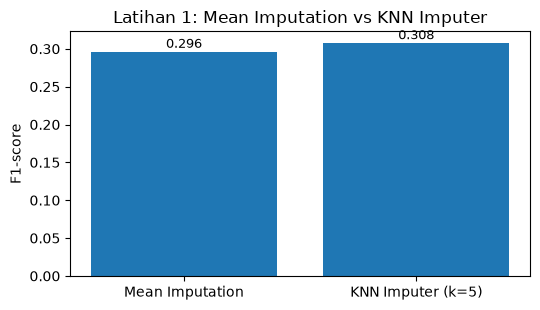

In [4]:
# Grafik Latihan 1: perbandingan F1 mean imputation vs KNN Imputer
hasil_imp = {}
for nama, imp in [("Mean Imputation", SimpleImputer(strategy="mean")),
                  ("KNN Imputer (k=5)", KNNImputer(n_neighbors=5))]:
    df_lat = df_missing.copy()
    df_lat[fitur_cols] = imp.fit_transform(df_missing[fitur_cols])
    df_lat = df_lat.dropna(subset=["target"])
    Xl, yl = df_lat[fitur_cols], df_lat["target"].astype(int)
    Xtr, Xte, ytr, yte = train_test_split(Xl, yl, test_size=0.2,
        stratify=yl, random_state=42)
    m_lat = LogisticRegression(max_iter=1000).fit(Xtr, ytr)
    hasil_imp[nama] = f1_score(yte, m_lat.predict(Xte))
plt.figure(figsize=(5.5, 3.2))
plt.bar(hasil_imp.keys(), hasil_imp.values())
plt.ylabel("F1-score")
plt.title("Latihan 1: Mean Imputation vs KNN Imputer")
for i, v in enumerate(hasil_imp.values()):
    plt.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

**Jawaban Latihan 1:** KNN Imputer (F1 0,308) sedikit mengungguli mean imputation (F1 0,296). Selisihnya kecil, tapi imputasi berbasis tetangga tetap lebih baik karena memanfaatkan pola antar-fitur, bukan sekadar rata-rata kolom.

### Latihan 2 (Praktikum 3.7) - Efektivitas Penanganan Imbalanced Data

**Soal (modul 3.10):** terapkan `RandomUnderSampler` dan `LogisticRegression(class_weight="balanced")`; bandingkan F1-Score keempat pendekatan (baseline, SMOTE, undersampling, class_weight); tulis kesimpulan pendekatan mana yang paling efektif.

In [5]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=42)
X_train_rus,y_train_rus = rus.fit_resample(X_train,y_train)
model_rus = LogisticRegression(max_iter=1000).fit(X_train_rus, y_train_rus)
model_cw = LogisticRegression(max_iter=1000, class_weight="balanced").fit(X_train,y_train)
# Bandingkan F1-Score keempat pendekatan: baseline, SMOTE, undersampling, class_weight
print(f"{'pendekatan':>14} | {'akurasi':>8} | {'F1':>7}")
print("-" * 37)
for nama, model in [("Baseline", model_base), ("SMOTE", model_smote),
                    ("Undersampling", model_rus), ("class_weight", model_cw)]:
    yp = model.predict(X_test)
    print(f"{nama:>14} | {accuracy_score(y_test, yp):>8.3f} | {f1_score(y_test, yp):>7.3f}")

    pendekatan |  akurasi |      F1
-------------------------------------
      Baseline |    0.953 |   0.308
         SMOTE |    0.836 |   0.367
 Undersampling |    0.802 |   0.336
  class_weight |    0.821 |   0.346


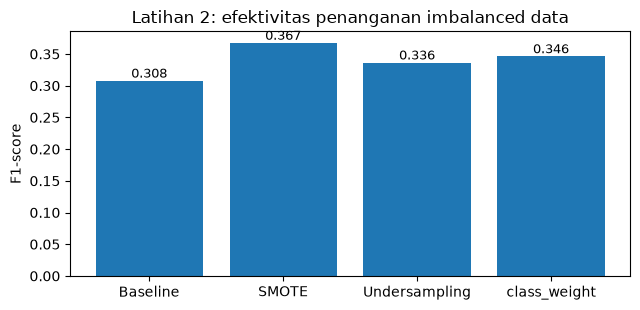

In [6]:
# Grafik Latihan 2: perbandingan F1 keempat pendekatan imbalance
hasil_imb = {}
for nama, model in [("Baseline", model_base), ("SMOTE", model_smote),
                    ("Undersampling", model_rus), ("class_weight", model_cw)]:
    hasil_imb[nama] = f1_score(y_test, model.predict(X_test))
plt.figure(figsize=(6.5, 3.2))
bars = plt.bar(hasil_imb.keys(), hasil_imb.values())
plt.ylabel("F1-score")
plt.title("Latihan 2: efektivitas penanganan imbalanced data")
for b, v in zip(bars, hasil_imb.values()):
    plt.text(b.get_x() + b.get_width()/2, v + 0.005, f"{v:.3f}",
             ha="center", fontsize=9)
plt.tight_layout()
plt.show()

**Kesimpulan Latihan 2:** SMOTE paling efektif untuk kasus ini dengan F1 tertinggi 0,367, disusul class_weight (0,346), undersampling (0,336), dan baseline terakhir (0,308). SMOTE menang karena menambah informasi kelas minoritas lewat sampel sintetis tanpa membuang data mayoritas, sedangkan undersampling kehilangan banyak data latih sehingga performanya turun.

## Kesimpulan Bab 3

1. **Imputasi berbasis tetangga sedikit lebih baik dari rata-rata kolom.** Pada Latihan 1, KNN Imputer menghasilkan F1 0,308 sedangkan mean imputation 0,296, karena KNN memanfaatkan pola antar-fitur, bukan sekadar rata-rata.
2. **Akurasi menipu pada data tidak seimbang.** Model baseline Latihan 2 mencapai akurasi 0,953 tapi F1 hanya 0,308, artinya model hampir selalu menebak kelas mayoritas dan gagal mengenali kelas minoritas.
3. **SMOTE paling efektif menangani imbalance untuk kasus ini.** Urutan F1: SMOTE 0,367, class_weight 0,346, undersampling 0,336, baseline 0,308. SMOTE menang karena menambah sampel sintetis kelas minoritas tanpa membuang data mayoritas.
4. **Penanganan data kotor harus dievaluasi dengan metrik yang tepat.** Baik imputasi maupun penyeimbangan kelas, kesimpulannya sama: pada data tidak seimbang, F1-score jauh lebih jujur dibanding akurasi untuk menilai kualitas model.